# Out-of-Distribution Robustness: Darcy Continuous

- PDE: $-\nabla \cdot (a \nabla u) = 10$, continuous coefficient function
- Latent dimension: $d = 6$

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

## 0. Config

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
from numpyro.diagnostics import effective_sample_size, split_gelman_rubin

from src.problems.darcy_continuous import (
    DarcyContinuous,
    mollifier,
    compute_pde_residual_single_sample,
)
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, chi2_ppc, nll_score,
    plot_field_comparison, plot_calibration, plot_posterior_gallery,
    plot_posterior_predictive, plot_trace, plot_metrics_table,
    plot_std_comparison_generic, plot_metrics_comparison_table_4way,
    plot_calibration_overlay, plot_physics_benefit_comparison,
    bootstrap_metric_ci, bootstrap_metric_difference_ci,
    compute_per_chain_metrics, format_significance_table,
    tune_sigma, recommended_nuts_config, mcmc_reliability_flag,
    compute_prior_predictive, build_prior_result,
    compute_error_std_correlation,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood, make_numpyro_model, make_numpyro_model_physics,
    sample_unconditional_prior, decode_posterior_batched,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics,
    build_mcmc_result, save_experiment_result, print_cross_seed_summary,
)
from src.utils.PlotFigure import Plot

# Paths
CHECKPOINT_PATH = Path('../runs/final_darcy_continuous/weights/best.pt')
IN_DATA_PATH = '../data/darcy_continuous/smh_test_in.mat'
OOD_DATA_PATH = '../data/darcy_continuous/smh_test_out.mat'

TEST_IDX = 0
if _task_id is not None:
    TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]
N_OBS = 100

# PDE collocation
NC_PDE = 50

# Sweep settings (tuned on in-domain only)
RHO_PDE_VALUES = [2.0, 1.0, 0.5, 0.3, 0.15, 0.1, 0.07, 0.05]
SWEEP_WARMUP = 1000
SWEEP_SAMPLES = 500

# Full run settings
NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

PROBLEM_NAME = 'ood_darcy_continuous'

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Setup

In [3]:
problem_in = DarcyContinuous(seed=42, test_data_path=IN_DATA_PATH)
params = load_problem(problem_in, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem_in, params)
log_prior_fn = make_log_prior(problem_in, params)

problem_ood = DarcyContinuous(seed=42, test_data_path=OOD_DATA_PATH)
problem_ood.initialize_models(problem_in.get_sample_inputs(batch_size=1))
problem_ood.load_checkpoint(CHECKPOINT_PATH)

n_points = problem_in.get_n_points()

print(f"Latent dim: {d}")
print(f"n_grid: {problem_in.n_grid}")

Loading data...


  Test: a=(200, 841, 1), u=(200, 841, 1)
Setting up grids and test functions...


  int_grid: (45, 2), v: (45, 1)
Building models...


  Initialized enc: 116,038 params


  Initialized u: 102,006 params
  Initialized a: 102,006 params


E0615 18:25:37.651812      23 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 10,280 params
Loading checkpoint: ../runs/final_darcy_continuous/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf


Loading data...
  Test: a=(200, 841, 1), u=(200, 841, 1)
Setting up grids and test functions...
  int_grid: (45, 2), v: (45, 1)
Building models...
  Initialized enc: 116,038 params
  Initialized u: 102,006 params
  Initialized a: 102,006 params
  Initialized nf: 10,280 params
Loading checkpoint: ../runs/final_darcy_continuous/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf
Latent dim: 6
n_grid: 45


## 2. PDE Collocation and Physics Closure

In [4]:
pde_rng = random.PRNGKey(123)
xc_fixed, R_fixed = problem_in.genPoint.weight_centers(
    n_center=NC_PDE, R_max=1e-4, R_min=1e-4, key=pde_rng,
)
x_pde_fixed = (problem_in.int_grid[None, :, :] * R_fixed + xc_fixed).reshape(-1, 2)

print(f"Fixed PDE grid: {x_pde_fixed.shape}  ({NC_PDE} centers x {problem_in.n_grid} pts)")


def log_pde_fn(beta, rho_pde):
    """PDE virtual-observable log-likelihood with fixed collocation points."""
    beta_b = beta[None, :]
    x_pde_b = x_pde_fixed[None, :, :]
    a_decoded = problem_in.models['a'].apply({'params': params['a']}, x_pde_b, beta_b)
    a_vals = a_decoded[0, :, None]
    residuals = compute_pde_residual_single_sample(
        params['u'], problem_in.models['u'], beta,
        xc_fixed, R_fixed, problem_in.int_grid, problem_in.v, problem_in.dv_dr,
        a_vals, problem_in.n_grid,
    )
    return -0.5 * jnp.sum(residuals ** 2) / (rho_pde ** 2)

Fixed PDE grid: (2250, 2)  (50 centers x 45 pts)


## 3. Prepare Observations (Seed-42 for tuning)

Same observation indices for both in-domain and OOD (sensor placement is not a confound).
Sigma tuning uses seed-42 observations; the multi-seed loop re-samples for full runs.

In [5]:
_rng_tune = random.PRNGKey(42)
_rng_tune, _key_tune = random.split(_rng_tune)

_obs_indices_tune = problem_in.sample_observation_indices(n_points, N_OBS, 'random', _key_tune)

obs_in_tune = problem_in.prepare_observations(sample_indices=[TEST_IDX], obs_indices=_obs_indices_tune)
obs_ood_tune = problem_ood.prepare_observations(sample_indices=[TEST_IDX], obs_indices=_obs_indices_tune)

print(f"In-domain  a_true range: [{float(obs_in_tune['a_true'].min()):.3f}, {float(obs_in_tune['a_true'].max()):.3f}]")
print(f"OOD        a_true range: [{float(obs_ood_tune['a_true'].min()):.3f}, {float(obs_ood_tune['a_true'].max()):.3f}]")

In-domain  a_true range: [1.103, 3.690]
OOD        a_true range: [2.774, 3.472]


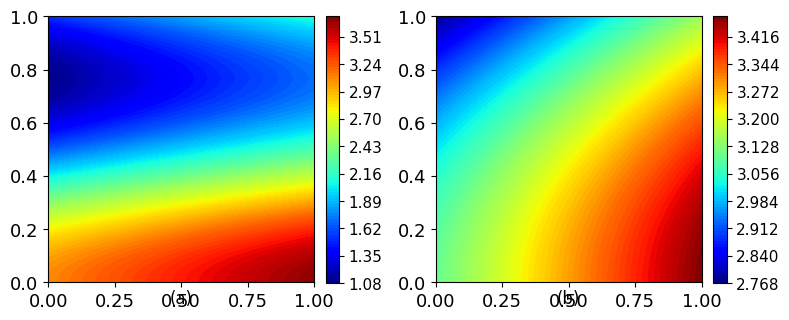

# (a) In-domain a_true  (b) OOD a_true


In [6]:
# Diagnostic: visualize coefficient fields
x_in_np = np.array(obs_in_tune['x_full'][0])
x_ood_np = np.array(obs_ood_tune['x_full'][0])
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
Plot.contourf_on_ax(axes[0], fig, x_in_np, np.array(obs_in_tune['a_true'][0, :, 0]), cmap='jet')
axes[0].text(0.5, -0.08, '(a)', transform=axes[0].transAxes, ha='center', fontsize=12)
axes[0].set_aspect('equal')
axes[0].tick_params(labelsize=13)
Plot.contourf_on_ax(axes[1], fig, x_ood_np, np.array(obs_ood_tune['a_true'][0, :, 0]), cmap='jet')
axes[1].text(0.5, -0.08, '(b)', transform=axes[1].transAxes, ha='center', fontsize=12)
axes[1].set_aspect('equal')
axes[1].tick_params(labelsize=13)
plt.tight_layout()
plt.show()
print("# (a) In-domain a_true  (b) OOD a_true")

## 4. MAP Baselines (Seed-42, Visualization)

In [7]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=50.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.8),
)

from src.evaluation.igno import IGNOInverter

# In-domain MAP (seed-42, visualization only)
_rng_tune, inv_rng = random.split(_rng_tune)
inverter_in_tune = IGNOInverter(problem_in, inv_rng)
beta_map_in_tune = inverter_in_tune.invert(
    obs_in_tune['x_obs'], obs_in_tune['u_obs'], obs_in_tune['x_full'], inv_config, verbose=True
)
preds_map_in_tune = problem_in.predict_from_beta(params, beta_map_in_tune, obs_in_tune['x_full'])
a_map_in_tune = preds_map_in_tune['a_pred'][0]
print(f"In-domain MAP RMSE(a): {rmse(a_map_in_tune, obs_in_tune['a_true'][0]):.6f}")

# OOD MAP (seed-42, visualization only)
_rng_tune, inv_rng = random.split(_rng_tune)
inverter_ood_tune = IGNOInverter(problem_ood, inv_rng)
beta_map_ood_tune = inverter_ood_tune.invert(
    obs_ood_tune['x_obs'], obs_ood_tune['u_obs'], obs_ood_tune['x_full'], inv_config, verbose=True
)
preds_map_ood_tune = problem_ood.predict_from_beta(params, beta_map_ood_tune, obs_ood_tune['x_full'])
a_map_ood_tune = preds_map_ood_tune['a_pred'][0]
print(f"OOD MAP RMSE(a): {rmse(a_map_ood_tune, obs_ood_tune['a_true'][0]):.6f}")

  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=50.0, target=u


Inverting:   0%|          | 0/200 [00:00<?, ?it/s]

Inverting:   0%|          | 1/200 [00:03<10:04,  3.04s/it]

Inverting:  40%|███▉      | 79/200 [00:03<00:03, 35.34it/s]

...

Inverting:  39%|███▉      | 78/200 [00:03<00:03, 36.73it/s, loss=3.4110, pde=1.3643, data=0.0409]

Inverting:  78%|███████▊  | 156/200 [00:03<00:00, 83.68it/s, loss=3.4110, pde=1.3643, data=0.0409]

Inverting:  78%|███████▊  | 156/200 [00:03<00:00, 83.68it/s, loss=2.7504, pde=1.1462, data=0.0321]

Inverting: 100%|██████████| 200/200 [00:03<00:00, 63.73it/s, loss=2.7504, pde=1.1462, data=0.0321]

Final: loss_pde=1.149297, loss_data=0.032056
OOD MAP RMSE(a): 0.113362


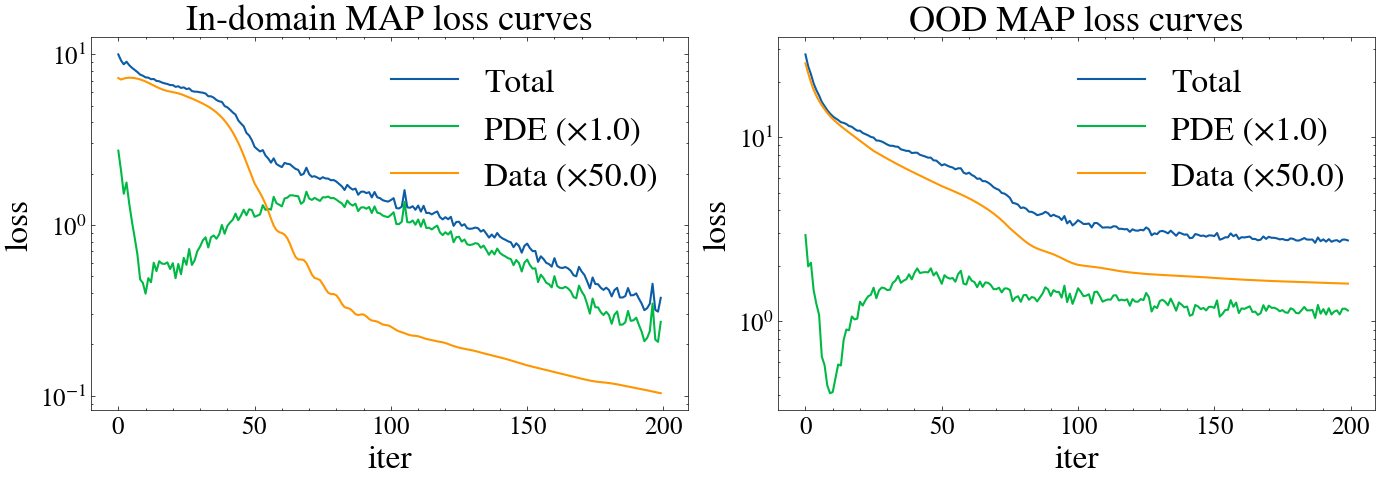

In [8]:
with plt.style.context(['science', 'no-latex']):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, inv, title in [(ax1, inverter_in_tune, 'In-domain'), (ax2, inverter_ood_tune, 'OOD')]:
        h = inv.loss_history
        for key, label in [
            ('total', 'Total'),
            ('weighted_pde', f'PDE (×{inv_config.loss_weights.pde})'),
            ('weighted_data', f'Data (×{inv_config.loss_weights.data})'),
        ]:
            ax.semilogy(np.array(h[key]), label=label, linewidth=1.5)
        ax.set_xlabel('iter')
        ax.set_ylabel('loss')
        ax.set_title(title + ' MAP loss curves')
        ax.legend()
    plt.tight_layout()
    _tune_fig_dir = Path(f'figures/{PROBLEM_NAME}/tuning')
    _tune_fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_tune_fig_dir / 'map_loss_curves_seed42.png')
    plt.show()

## 5. Sigma Tuning (In-Domain, Seed-42)

Sigma is computed via pilot MCMC chains on seed-42 in-domain observations.
Per-seed sigma is re-tuned inside the main loop.

In [9]:
log_lik_in_tune = make_gaussian_log_likelihood(
    problem_in, params, mollifier,
    obs_in_tune['x_obs'], obs_in_tune['u_obs'],
)

_model_tune = make_numpyro_model(d, log_prior_fn, log_lik_in_tune)


def _decode_fn_tune(beta_samples):
    a_samples, _ = decode_posterior_batched(
        problem_in, params, jnp.array(beta_samples), obs_in_tune['x_full'], batch_size=200,
    )
    return a_samples


def _model_factory_tune(sigma):
    def _model():
        _model_tune(sigma=sigma)
    return _model


_rng_tune, tune_key = random.split(_rng_tune)
SIGMA, _ = tune_sigma(
    model_fn_factory=_model_factory_tune,
    beta_mode=beta_mode,
    sigma_candidates=[0.005, 0.01, 0.02, 0.04, 0.08, 0.15],
    rng_key=tune_key,
    decode_fn=_decode_fn_tune,
    a_true=np.array(obs_in_tune['a_true'][0, :, 0]),
    pilot_warmup=2000,
    pilot_samples=500,
    pilot_chains=2,
)
print(f"Sigma from tune_sigma (seed-42, in-domain): {SIGMA:.6f}")

  Sigma tuning (6 candidates, 2000 warmup + 500 samples × 2 chains):


    sigma=0.0050  cov=0.961  ESS_min=96.2  R-hat=1.026  div=0  OK


    sigma=0.0100  cov=0.986  ESS_min=150.3  R-hat=1.005  div=0  OK


    sigma=0.0200  cov=0.990  ESS_min=163.6  R-hat=1.009  div=0  OK


    sigma=0.0400  cov=0.989  ESS_min=142.8  R-hat=1.017  div=0  OK


    sigma=0.0800  cov=0.979  ESS_min=96.7  R-hat=1.012  div=0  OK


    sigma=0.1500  cov=0.879  ESS_min=21.4  R-hat=1.089  div=2  OK
  Selected sigma=0.005  (coverage=0.961, ESS_min=96.2)
Sigma from tune_sigma (seed-42, in-domain): 0.005000


## 6. Rho_pde Tuning (In-Domain Only)

Sweep physics constraint strength on in-domain data. Same rho applied to OOD.

In [10]:
model_physics_tune = make_numpyro_model_physics(d, log_prior_fn, log_lik_in_tune, log_pde_fn)

# Quick in-domain data-only baseline (for rho selection threshold)
_baseline_nuts_cfg = recommended_nuts_config(d, SIGMA)
kernel = NUTS(_model_tune,
              init_strategy=init_to_value(values={"beta": beta_mode}),
              target_accept_prob=0.8,
              dense_mass=_baseline_nuts_cfg.get('dense_mass', False))
_rng_tune, mcmc_key = random.split(_rng_tune)
mcmc_baseline = MCMC(kernel, num_warmup=SWEEP_WARMUP, num_samples=SWEEP_SAMPLES,
                     num_chains=1, progress_bar=True)
_t_pilot = time.time()
mcmc_baseline.run(mcmc_key, sigma=SIGMA)
print(f"  Pilot baseline completed in {time.time() - _t_pilot:.1f}s")

beta_baseline = mcmc_baseline.get_samples()["beta"]
ess_baseline = effective_sample_size(np.array(beta_baseline)[None])
dec_baseline_m = compute_standard_metrics(
    np.array(decode_posterior_batched(problem_in, params, beta_baseline, obs_in_tune['x_full'], batch_size=200)[0]),
    np.array(obs_in_tune['a_true'][0, :, 0]),
)
baseline_a_err = dec_baseline_m['a_err']
print(f"In-domain data-only baseline: a_err={baseline_a_err:.4f}, coverage={dec_baseline_m['coverage_95']:.2%}")

  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:04<1:50:43,  4.43s/it, 1 steps of size 2.34e+00. acc. prob=0.00]

warmup:   1%|▏         | 19/1500 [00:04<04:14,  5.82it/s, 31 steps of size 8.86e-04. acc. prob=0.64]

warmup:   2%|▏         | 29/1500 [00:04<02:51,  8.56it/s, 63 steps of size 8.93e-04. acc. prob=0.68]

warmup:   2%|▏         | 36/1500 [00:05<02:24, 10.14it/s, 255 steps of size 5.78e-04. acc. prob=0.70]

...

sample:  98%|█████████▊| 1466/1500 [00:17<00:00, 191.14it/s, 7 steps of size 3.87e-01. acc. prob=0.92]

sample:  99%|█████████▉| 1486/1500 [00:17<00:00, 183.58it/s, 7 steps of size 3.87e-01. acc. prob=0.92]

sample: 100%|██████████| 1500/1500 [00:17<00:00, 83.78it/s, 15 steps of size 3.87e-01. acc. prob=0.92]

  Pilot baseline completed in 18.4s


In-domain data-only baseline: a_err=0.0115, coverage=96.31%


In [11]:
print(f"Rho sweep on IN-DOMAIN: {SWEEP_WARMUP} warmup, {SWEEP_SAMPLES} samples per rho")
print(f"rho values: {RHO_PDE_VALUES}")

sweep_results = []
for rho in RHO_PDE_VALUES:
    print(f"\n{'='*60}\nrho_pde = {rho}\n{'='*60}")
    _rng_tune, key = random.split(_rng_tune)
    kernel = NUTS(model_physics_tune,
                  init_strategy=init_to_value(values={"beta": beta_mode}),
                  target_accept_prob=0.8,
                  dense_mass=_baseline_nuts_cfg.get('dense_mass', False))
    mcmc = MCMC(kernel, num_warmup=SWEEP_WARMUP, num_samples=SWEEP_SAMPLES,
                num_chains=1, progress_bar=True)
    _t_pilot = time.time()
    mcmc.run(key, sigma=SIGMA, rho_pde=rho, extra_fields=('diverging',))
    print(f"  Pilot rho={rho} completed in {time.time() - _t_pilot:.1f}s")

    beta_s = mcmc.get_samples()["beta"]
    n_div = int(mcmc.get_extra_fields()['diverging'].sum())
    dec = compute_standard_metrics(
        np.array(decode_posterior_batched(problem_in, params, beta_s, obs_in_tune['x_full'], batch_size=200)[0]),
        np.array(obs_in_tune['a_true'][0, :, 0]),
    )
    ess = effective_sample_size(np.array(beta_s)[None, :, :])

    sweep_results.append({
        'rho_pde': rho, 'a_err': dec['a_err'], 'coverage': dec['coverage_95'],
        'ess_min': float(ess.min()), 'n_div': n_div, 'crps_a': dec['crps_a'],
    })
    print(f"  a_err={dec['a_err']:.4f}  coverage={dec['coverage_95']:.2%}  "
          f"ESS_min={float(ess.min()):.1f}  n_div={n_div}")

# Select best rho
a_err_threshold = baseline_a_err * 2
candidates = [(abs(r['coverage'] - 0.95), r) for r in sweep_results
              if r['a_err'] <= a_err_threshold]
if candidates:
    candidates.sort(key=lambda x: x[0])
    BEST_RHO_PDE = candidates[0][1]['rho_pde']
else:
    BEST_RHO_PDE = max(RHO_PDE_VALUES)
    print("No candidate with a_err <= 2x baseline; using largest rho.")

print(f"\nSelected BEST_RHO_PDE = {BEST_RHO_PDE}")

Rho sweep on IN-DOMAIN: 1000 warmup, 500 samples per rho
rho values: [2.0, 1.0, 0.5, 0.3, 0.15, 0.1, 0.07, 0.05]

rho_pde = 2.0


  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:07<3:12:53,  7.72s/it, 1 steps of size 2.34e+00. acc. prob=0.00]

warmup:   1%|          | 8/1500 [00:07<17:46,  1.40it/s, 7 steps of size 2.18e-03. acc. prob=0.46]  

warmup:   1%|          | 16/1500 [00:08<07:30,  3.29it/s, 127 steps of size 1.14e-03. acc. prob=0.62]

...

sample:  99%|█████████▊| 1480/1500 [00:28<00:00, 124.16it/s, 7 steps of size 5.11e-01. acc. prob=0.91]

sample: 100%|█████████▉| 1493/1500 [00:28<00:00, 122.60it/s, 7 steps of size 5.11e-01. acc. prob=0.91]

sample: 100%|██████████| 1500/1500 [00:28<00:00, 52.22it/s, 7 steps of size 5.11e-01. acc. prob=0.91] 

  Pilot rho=0.05 completed in 29.5s


  a_err=0.0050  coverage=96.08%  ESS_min=473.4  n_div=0

Selected BEST_RHO_PDE = 0.07


## 7. Run Condition Helper

In [12]:
def run_condition(model_fn, model_kwargs, x_full_ref, a_true_ref, obs_indices,
                  u_obs_np, label, seed, problem_ref):
    """Run MCMC for one condition, decode, and compute metrics."""
    print(f"\n{'='*60}\n  {label}\n{'='*60}")

    nuts_cfg = recommended_nuts_config(d, model_kwargs['sigma'])
    print(f"  NUTS config: {nuts_cfg}")

    rng_local = random.PRNGKey(seed)
    mcmc, timing = run_mcmc(
        model_fn, {"beta": beta_mode}, model_kwargs, rng_local,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )
    mcmc.print_summary(exclude_deterministic=True)

    diag = extract_mcmc_diagnostics(mcmc, sample_name="beta",
                                    total_samples=NUM_CHAINS * NUM_SAMPLES)

    a_samples, u_samples = decode_posterior_batched(
        problem_ref, params, diag['samples'], x_full_ref, batch_size=200,
    )

    a_true_np = np.array(a_true_ref[0, :, 0])
    metrics = compute_standard_metrics(a_samples, a_true_np)

    a_std = np.std(a_samples, axis=0)
    a_mean = np.mean(a_samples, axis=0)
    spearman_rho, spearman_p = compute_error_std_correlation(a_true_np, a_mean, a_std)

    u_pred_at_obs = u_samples[:, obs_indices]
    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, model_kwargs['sigma'])
    print(f"  {label}: chi2={chi2_stat:.2f}, p={chi2_pval:.4f}")

    return {
        'label': label,
        'a_samples': a_samples,
        'u_samples': u_samples,
        'a_mean': a_mean,
        'a_std': a_std,
        'u_mean': np.mean(u_samples, axis=0),
        **metrics,
        'sigma': model_kwargs['sigma'],
        'ess_min': diag['ess_min'],
        'rhat_max': diag['rhat_max'],
        'rhat_mean': diag['rhat_mean'],
        'n_div': diag['n_div'],
        'reliability_flag': diag['flag'],
        'reliability_explanation': diag['flag_explanation'],
        'chi2_ppc': chi2_stat,
        'chi2_ppc_pvalue': chi2_pval,
        'spearman_rho_error_std': float(spearman_rho),
        'spearman_pvalue_error_std': float(spearman_p),
        'warmup_time_s': timing['warmup_time_s'],
        'sampling_time_s': timing['sampling_time_s'],
        'step_time_s': timing['step_time_s'],
        'beta_by_chain': diag['by_chain'],
        'beta_for_trace': diag['by_chain'][0],
        'ess': diag['ess'],
        'rhat': diag['rhat'],
    }

## 8. Multi-Seed Full MCMC — 4 Conditions

| | Data-only | Physics-informed |
|---|---|---|
| **In-domain** | (a) | (b) |
| **OOD** | (c) | (d) |


######################################################################
## SEED = 123
######################################################################
  Inversion grid: n_mesh_or_grid=7, n_grid=25
Loss weights: pde=1.0, data=50.0, target=u


Final: loss_pde=0.414489, loss_data=0.002719
MAP (in-domain) completed in 3.6s
[seed=123] In-domain MAP RMSE(a): 0.010908
  Inversion grid: n_mesh_or_grid=7, n_grid=25
Loss weights: pde=1.0, data=50.0, target=u


Final: loss_pde=1.421060, loss_data=0.042124
MAP (OOD) completed in 3.6s
[seed=123] OOD MAP RMSE(a): 0.111727


Prior (in-domain): a_err=0.2562, CRPS=0.3770
Prior (OOD):       a_err=0.2688, CRPS=0.4999
  Sigma tuning (6 candidates, 2000 warmup + 500 samples × 2 chains):


    sigma=0.0050  cov=0.979  ESS_min=120.4  R-hat=1.027  div=0  OK


...

sample: 100%|██████████| 2000/2000 [00:35<00:00, 56.08it/s]

MCMC warmup: 176.5s, sampling: 35.7s

                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.38      0.02      0.37      0.35      0.41      2.78      1.80
   beta[1]     -0.11      0.07     -0.08     -0.23     -0.06      2.07      5.14
   beta[2]     -0.43      0.15     -0.50     -0.55     -0.15      2.03      7.65
   beta[3]      0.68      0.02      0.67      0.64      0.72      3.89      1.39
   beta[4]      0.32      0.16      0.41      0.03      0.45      2.03      7.57
   beta[5]      0.20      0.09      0.24      0.04      0.27      2.04      6.91

Number of divergences: 0
ESS min=2.0, R-hat max=7.6508, divergences=0/8000, [FAIL] ESS_min=2.0 < 10; R-hat_max=7.651 > 1.2


  OOD Physics: chi2=16.41, p=1.0000

  Darcy Continuous — sigma=0.005, rho_pde=0.07 (seed=123)
  Metric                          In-DO          In-Phys           OOD-DO         OOD-Phys
  ------------------------------------------------------------------------------------
  Rel. L2 (a)                  0.011262         0.006100         0.129488         0.032068
  CRPS (a)                     0.013120         0.008076         0.188476         0.051157
  NLL (a)                     -2.493426        -2.880386         0.187646        -0.678801
  95% Coverage                 0.975030         0.970273         0.819263         0.633769
  CI Width (a)                 0.089909         0.062285         0.814708         0.340033
  Sharpness (mean std)         0.022905         0.015815         0.358169         0.112473
  ESS min                   3655.964506      8281.168052         2.004748         2.030961
  R-hat max                    1.000818         1.000308        20.430674         7.650830

──────────────────────────────────────────────────────────────────────────────────
  Darcy Continuous — RQ3: Pairwise Contrasts (Bootstrap, seed=123)
──────────────────────────────────────────────────────────────────────────────────
  (a) In-Phys CRPS diff (DO - Phys)       diff=+0.00504  CI [+0.00478, +0.00532]  *
  (a) In-Phys Coverage diff (DO - Phys)   diff=+0.00476  CI [-0.00357, +0.00951]  n.s.
  (a) In-Phys CI Width diff (DO - Phys)   diff=+0.02762  CI [+0.02603, +0.02913]  *
  (b) OOD-Phys CRPS diff (DO - Phys)      diff=+0.13732  CI [+0.12936, +0.14470]  *
  (b) OOD-Phys Coverage diff (DO - Phys)  diff=+0.18549  CI [+0.17955, +0.19620]  *
  (b) OOD-Phys CI Width diff (DO - Phys)  diff=+0.47467  CI [+0.47205, +0.47692]  *
  (c) OOD degradation CRPS (DO)           diff=-0.75896  CI [-0.76592, -0.75218]  *
  (d) OOD degradation CRPS (Phys)         diff=-0.90999  CI [-0.91092, -0.90904]  *
──────────────────────────────────────────────────────────────────────────────────
  Signifi

──────────────────────────────────────────────────────────────────────────────────
  Darcy Continuous — Physics Benefit Analysis (seed=123)
──────────────────────────────────────────────────────────────────────────────────
  Δ CRPS In-Domain (phys − do)            diff=-0.00504  CI [-0.00531, -0.00476]  *
  Δ CRPS OOD (phys − do)                  diff=-0.13732  CI [-0.14461, -0.13056]  *
  Δ CRPS DoD (ood_delta − id_delta)       diff=-0.13205  CI [-0.13972, -0.12472]  *
──────────────────────────────────────────────────────────────────────────────────
  Significance: ** p<0.01  * p<0.05  ~ p<0.1  n.s. not significant
  Bootstrap CIs reflect MCMC finite-sample variability, not posterior uncertainty.
──────────────────────────────────────────────────────────────────────────────────
Negative Δ CRPS = physics improves. Positive DoD = OOD benefits more from physics.


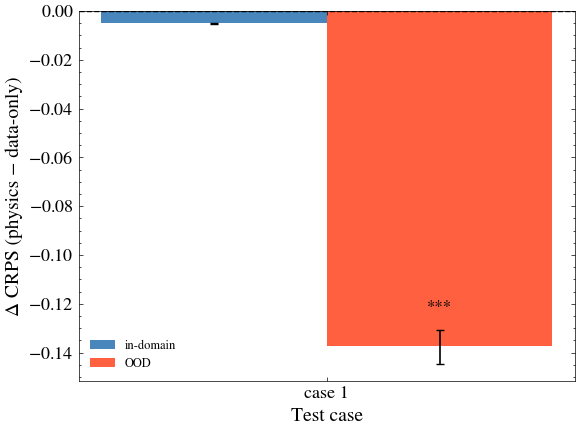

Saved structured result to: /workspace/experiments/results/structured/ood/darcy_continuous_2026-06-15T23-38-07_seed123_test2.json


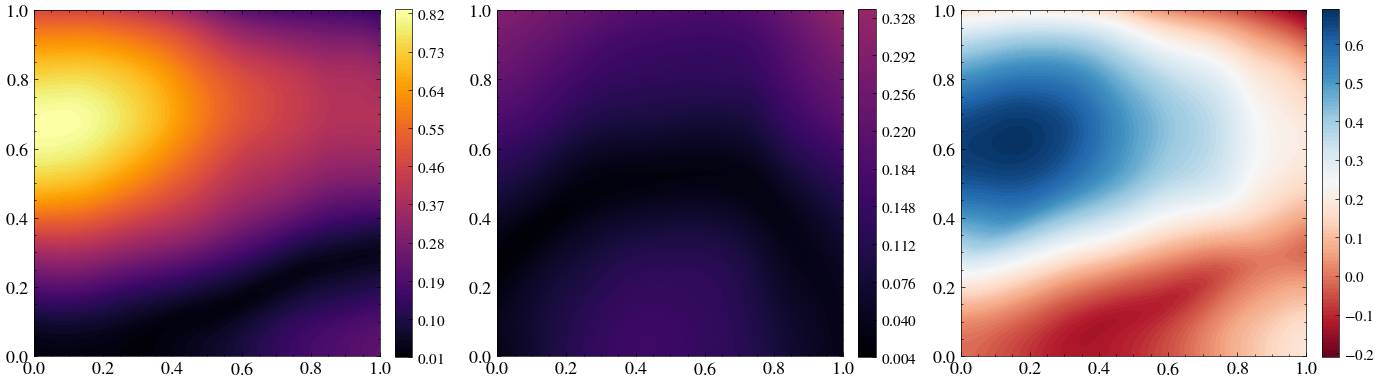

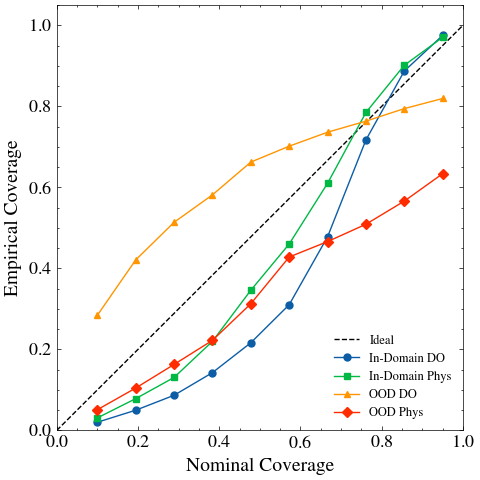

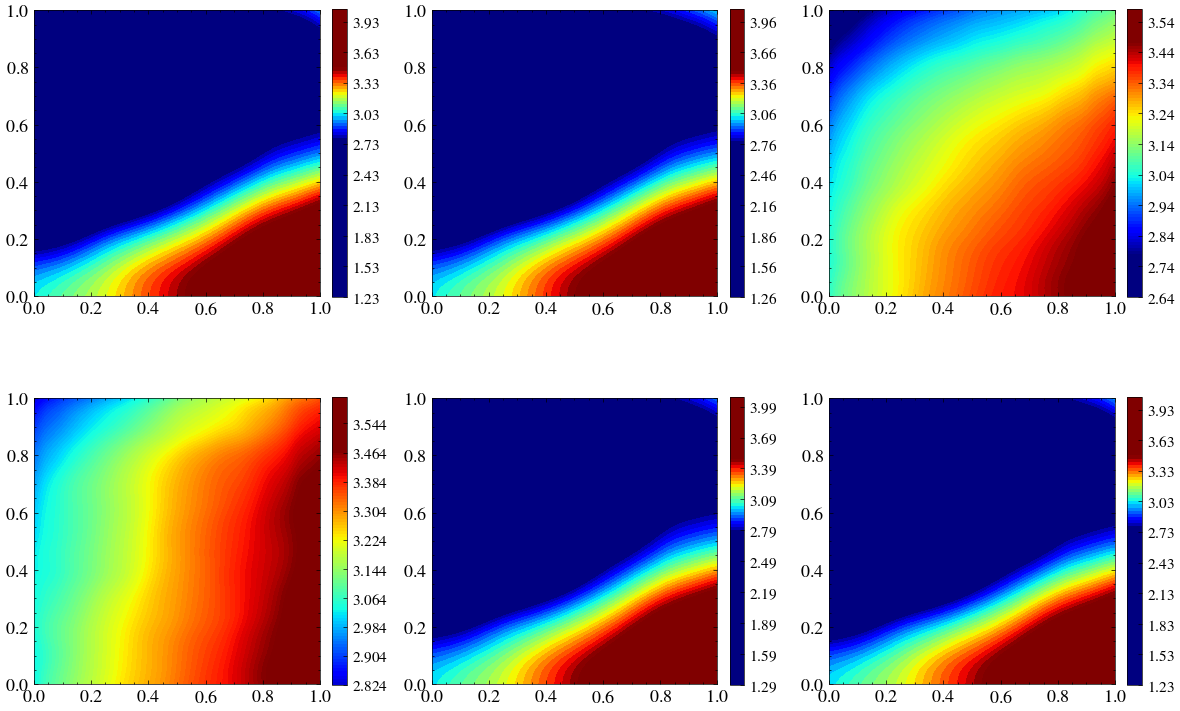

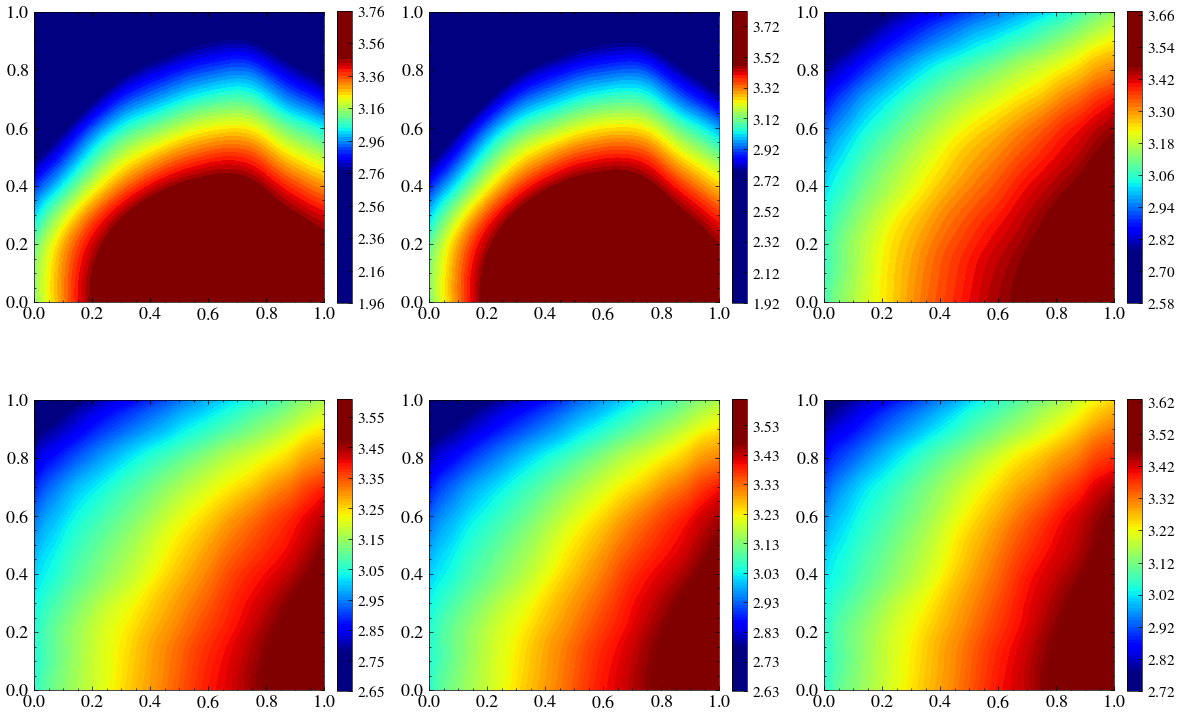


OOD Data-Only per-dimension diagnostics (4 chains):
 dim       ESS     R-hat        mean         std
   0       2.0    9.2404      0.6191      0.2480
   1       2.0   17.4939      0.3368      0.4206
   2       2.0   11.4898     -0.2594      0.2666
   3       2.0   11.6344      0.4889      0.1836
   4       2.0   20.4307     -0.0977      0.5158
   5       2.0    7.2217      0.1042      0.1345
Divergences: 1 / 8000
ESS min: 2.0, R-hat max: 20.4307, R-hat mean: 12.9185


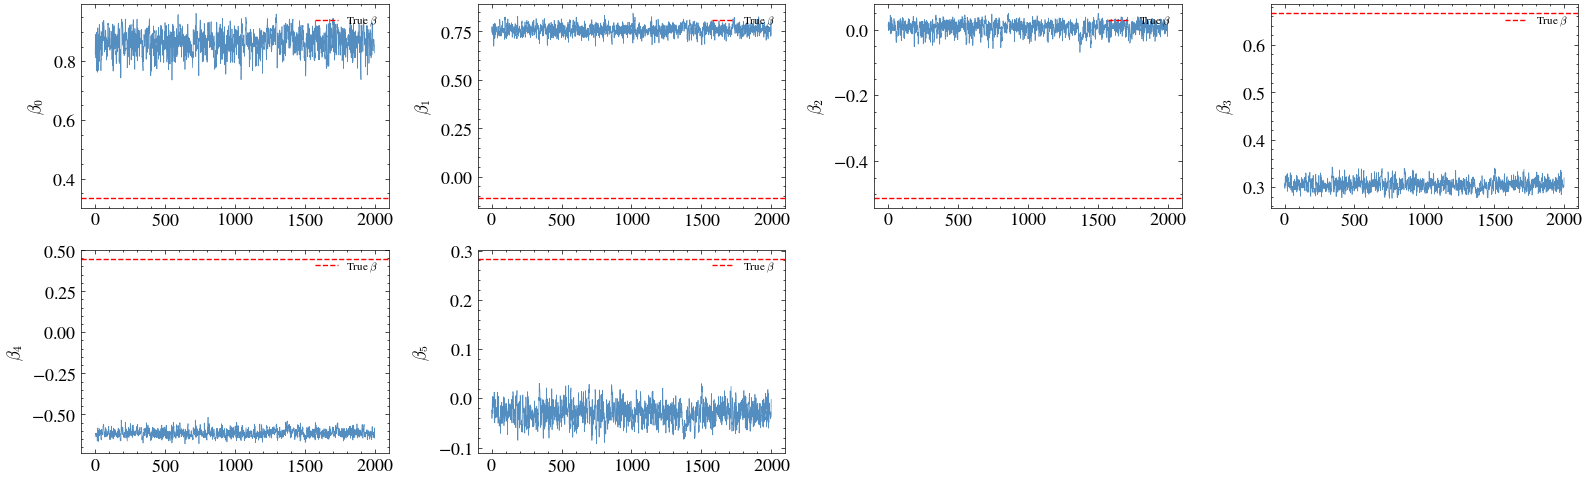


OOD Physics per-dimension diagnostics (4 chains):
 dim       ESS     R-hat        mean         std
   0       2.8    1.7989      0.3773      0.0184
   1       2.1    5.1385     -0.1136      0.0651
   2       2.0    7.6508     -0.4253      0.1545
   3       3.9    1.3937      0.6768      0.0227
   4       2.0    7.5691      0.3240      0.1600
   5       2.0    6.9146      0.2002      0.0904
Divergences: 0 / 8000
ESS min: 2.0, R-hat max: 7.6508, R-hat mean: 5.0776


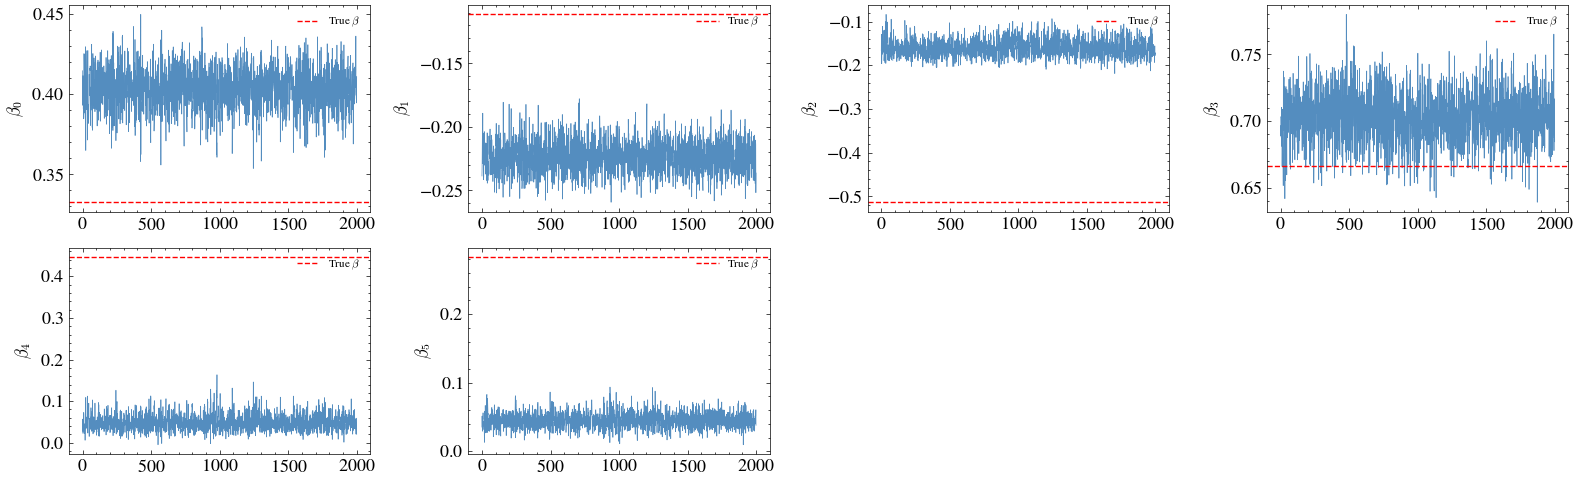

In [13]:
from results_schema import ExperimentResult
from datetime import datetime

for SEED in SEEDS:
    print(f"\n{'#'*70}\n## SEED = {SEED}\n{'#'*70}")
    _t_total_start = time.time()

    FIGURE_DIR = Path(f'figures/{PROBLEM_NAME}/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # Fresh observations per seed (shared indices for in-domain and OOD)
    _rng_seed = random.PRNGKey(SEED)
    _rng_seed, _key_obs = random.split(_rng_seed)
    _obs_indices_seed = problem_in.sample_observation_indices(n_points, N_OBS, 'random', _key_obs)

    obs_in = problem_in.prepare_observations(sample_indices=[TEST_IDX], obs_indices=_obs_indices_seed)
    obs_ood = problem_ood.prepare_observations(sample_indices=[TEST_IDX], obs_indices=_obs_indices_seed)

    x_full_in, x_obs_in, u_obs_in = obs_in['x_full'], obs_in['x_obs'], obs_in['u_obs']
    a_true_in, u_true_in = obs_in['a_true'], obs_in['u_true']

    x_full_ood, x_obs_ood, u_obs_ood = obs_ood['x_full'], obs_ood['x_obs'], obs_ood['u_obs']
    a_true_ood, u_true_ood = obs_ood['a_true'], obs_ood['u_true']

    # === MAP Baselines ===
    _rng_seed, key1, key2 = random.split(_rng_seed, 3)

    # In-domain MAP
    inverter_in = IGNOInverter(problem_in, key1)
    _t_map_in = time.time()
    beta_map_in = inverter_in.invert(x_obs_in, u_obs_in, x_full_in, inv_config, verbose=False)
    _map_in_time_s = time.time() - _t_map_in
    print(f"MAP (in-domain) completed in {_map_in_time_s:.1f}s")
    preds_map_in = problem_in.predict_from_beta(params, beta_map_in, x_full_in)
    a_map_in = preds_map_in['a_pred'][0]
    rmse_map_in = float(rmse(a_map_in, a_true_in[0]))
    print(f"[seed={SEED}] In-domain MAP RMSE(a): {rmse_map_in:.6f}")

    # OOD MAP
    inverter_ood = IGNOInverter(problem_ood, key2)
    _t_map_ood = time.time()
    beta_map_ood = inverter_ood.invert(x_obs_ood, u_obs_ood, x_full_ood, inv_config, verbose=False)
    _map_ood_time_s = time.time() - _t_map_ood
    print(f"MAP (OOD) completed in {_map_ood_time_s:.1f}s")
    preds_map_ood = problem_ood.predict_from_beta(params, beta_map_ood, x_full_ood)
    a_map_ood = preds_map_ood['a_pred'][0]
    rmse_map_ood = float(rmse(a_map_ood, a_true_ood[0]))
    print(f"[seed={SEED}] OOD MAP RMSE(a): {rmse_map_ood:.6f}")

    # === Prior Predictive Baseline ===
    a_true_in_np = np.array(a_true_in[0, :, 0])
    a_true_ood_np = np.array(a_true_ood[0, :, 0])

    prior_a_samples, prior_metrics_in, _rng_seed = sample_unconditional_prior(
        problem_in, params, x_full_in, a_true_in_np, _rng_seed,
    )
    prior_metrics_ood = compute_prior_predictive(prior_a_samples, a_true_ood_np)
    print(f"Prior (in-domain): a_err={prior_metrics_in['a_err']:.4f}, CRPS={prior_metrics_in['crps_a']:.4f}")
    print(f"Prior (OOD):       a_err={prior_metrics_ood['a_err']:.4f}, CRPS={prior_metrics_ood['crps_a']:.4f}")

    # === Per-seed sigma tuning ===
    log_lik_in_seed = make_gaussian_log_likelihood(problem_in, params, mollifier, x_obs_in, u_obs_in)
    _model_seed = make_numpyro_model(d, log_prior_fn, log_lik_in_seed)

    def _seed_decode_fn(beta_samples):
        a_s, _ = decode_posterior_batched(
            problem_in, params, jnp.array(beta_samples), x_full_in, batch_size=200,
        )
        return a_s

    def _seed_model_factory(sigma):
        def _model():
            _model_seed(sigma=sigma)
        return _model

    _rng_seed, tune_key = random.split(_rng_seed)
    SIGMA, _ = tune_sigma(
        model_fn_factory=_seed_model_factory,
        beta_mode=beta_mode,
        sigma_candidates=[0.005, 0.01, 0.02, 0.04, 0.08, 0.15],
        rng_key=tune_key,
        decode_fn=_seed_decode_fn,
        a_true=a_true_in_np,
        pilot_warmup=2000,
        pilot_samples=500,
        pilot_chains=2,
    )
    print(f"Sigma from tune_sigma: {SIGMA:.6f}")

    # === Build per-seed models (capture likelihoods at creation time) ===
    log_lik_ood_seed = make_gaussian_log_likelihood(problem_in, params, mollifier, x_obs_ood, u_obs_ood)

    model_in_do   = make_numpyro_model(d, log_prior_fn, log_lik_in_seed)
    model_in_phys = make_numpyro_model_physics(d, log_prior_fn, log_lik_in_seed, log_pde_fn)
    model_ood_do  = make_numpyro_model(d, log_prior_fn, log_lik_ood_seed)
    model_ood_phys = make_numpyro_model_physics(d, log_prior_fn, log_lik_ood_seed, log_pde_fn)

    _u_obs_in_np  = np.array(u_obs_in[0, :, 0])
    _u_obs_ood_np = np.array(u_obs_ood[0, :, 0])

    # === 4 Conditions ===
    res_in_do = run_condition(
        model_in_do, {"sigma": SIGMA},
        x_full_in, a_true_in, _obs_indices_seed, _u_obs_in_np,
        "In-domain Data-Only", seed=SEED+0, problem_ref=problem_in,
    )
    res_in_phys = run_condition(
        model_in_phys, {"sigma": SIGMA, "rho_pde": BEST_RHO_PDE},
        x_full_in, a_true_in, _obs_indices_seed, _u_obs_in_np,
        "In-domain Physics", seed=SEED+1, problem_ref=problem_in,
    )
    res_ood_do = run_condition(
        model_ood_do, {"sigma": SIGMA},
        x_full_ood, a_true_ood, _obs_indices_seed, _u_obs_ood_np,
        "OOD Data-Only", seed=SEED+2, problem_ref=problem_in,
    )
    res_ood_phys = run_condition(
        model_ood_phys, {"sigma": SIGMA, "rho_pde": BEST_RHO_PDE},
        x_full_ood, a_true_ood, _obs_indices_seed, _u_obs_ood_np,
        "OOD Physics", seed=SEED+3, problem_ref=problem_in,
    )

    # -- Metrics Comparison --
    def make_metrics_dict(res):
        return {
            'Rel. L2 (a)': res['a_err'],
            'CRPS (a)': res['crps_a'],
            'NLL (a)': res['nll_a'],
            '95% Coverage': res['coverage_95'],
            'CI Width (a)': res['ci_width'],
            'Sharpness (mean std)': float(np.mean(res['a_std'])),
            'ESS min': res['ess_min'],
            'R-hat max': res['rhat_max'],
            'Divergences': res['n_div'],
        }

    plot_metrics_comparison_table_4way(
        make_metrics_dict(res_in_do),
        make_metrics_dict(res_in_phys),
        make_metrics_dict(res_ood_do),
        make_metrics_dict(res_ood_phys),
        title=f'Darcy Continuous — sigma={SIGMA}, rho_pde={BEST_RHO_PDE} (seed={SEED})',
    )

    # -- Significance of Pairwise Contrasts --
    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))
    def _coverage_95(s, t):
        _, emp = compute_calibration(s, t, np.array([0.95]))
        return float(emp[0])
    def _ci_width(s, t): return ci_width_95(s)

    rng_bs = np.random.default_rng(SEED)

    d_in_phys_crps  = bootstrap_metric_difference_ci(res_in_do['a_samples'], res_in_phys['a_samples'], a_true_in_np, _crps_a, rng=rng_bs)
    d_in_phys_cov   = bootstrap_metric_difference_ci(res_in_do['a_samples'], res_in_phys['a_samples'], a_true_in_np, _coverage_95, rng=rng_bs)
    d_in_phys_width = bootstrap_metric_difference_ci(res_in_do['a_samples'], res_in_phys['a_samples'], a_true_in_np, _ci_width, rng=rng_bs)
    d_ood_phys_crps  = bootstrap_metric_difference_ci(res_ood_do['a_samples'], res_ood_phys['a_samples'], a_true_ood_np, _crps_a, rng=rng_bs)
    d_ood_phys_cov   = bootstrap_metric_difference_ci(res_ood_do['a_samples'], res_ood_phys['a_samples'], a_true_ood_np, _coverage_95, rng=rng_bs)
    d_ood_phys_width = bootstrap_metric_difference_ci(res_ood_do['a_samples'], res_ood_phys['a_samples'], a_true_ood_np, _ci_width, rng=rng_bs)
    d_ood_do_crps    = bootstrap_metric_difference_ci(res_ood_do['a_samples'], res_in_do['a_samples'], a_true_ood_np, _crps_a, rng=rng_bs)
    d_ood_phys_deg   = bootstrap_metric_difference_ci(res_ood_phys['a_samples'], res_in_phys['a_samples'], a_true_ood_np, _crps_a, rng=rng_bs)

    format_significance_table({
        '(a) In-Phys CRPS diff (DO - Phys)':      d_in_phys_crps,
        '(a) In-Phys Coverage diff (DO - Phys)':  d_in_phys_cov,
        '(a) In-Phys CI Width diff (DO - Phys)':  d_in_phys_width,
        '(b) OOD-Phys CRPS diff (DO - Phys)':     d_ood_phys_crps,
        '(b) OOD-Phys Coverage diff (DO - Phys)': d_ood_phys_cov,
        '(b) OOD-Phys CI Width diff (DO - Phys)': d_ood_phys_width,
        '(c) OOD degradation CRPS (DO)':           d_ood_do_crps,
        '(d) OOD degradation CRPS (Phys)':         d_ood_phys_deg,
    }, title=f'Darcy Continuous — RQ3: Pairwise Contrasts (Bootstrap, seed={SEED})')
    print("Negative CRPS/CI-Width diff = improved; positive Coverage diff = improved.")
    print("Note: 4 contrasts x 3 metrics = 12 tests; Bonferroni threshold 0.05/12 ≈ 0.004")

    # -- Physics Benefit Delta Analysis (RQ3 Hardening) --
    _rng_pb = np.random.default_rng(SEED + 5000)

    delta_in_crps  = bootstrap_metric_difference_ci(res_in_phys['a_samples'],  res_in_do['a_samples'],  a_true_in_np,  _crps_a, rng=_rng_pb)
    delta_ood_crps = bootstrap_metric_difference_ci(res_ood_phys['a_samples'], res_ood_do['a_samples'], a_true_ood_np, _crps_a, rng=_rng_pb)

    ci_in_do_pb    = bootstrap_metric_ci(res_in_do['a_samples'],   a_true_in_np,  _crps_a, rng=_rng_pb)
    ci_in_phys_pb  = bootstrap_metric_ci(res_in_phys['a_samples'], a_true_in_np,  _crps_a, rng=_rng_pb)
    ci_ood_do_pb   = bootstrap_metric_ci(res_ood_do['a_samples'],  a_true_ood_np, _crps_a, rng=_rng_pb)
    ci_ood_phys_pb = bootstrap_metric_ci(res_ood_phys['a_samples'],a_true_ood_np, _crps_a, rng=_rng_pb)

    # Difference-of-differences: positive = OOD benefits more from physics
    _n_dod = 1000
    _dod_samples = np.empty(_n_dod)
    _rng_dod = np.random.default_rng(SEED + 6000)
    _na_in_do,  _na_in_p   = res_in_do['a_samples'].shape[0],  res_in_phys['a_samples'].shape[0]
    _na_ood_do, _na_ood_p  = res_ood_do['a_samples'].shape[0], res_ood_phys['a_samples'].shape[0]
    for _i in range(_n_dod):
        _b_in_do  = res_in_do['a_samples'][_rng_dod.integers(0, _na_in_do,  _na_in_do)]
        _b_in_p   = res_in_phys['a_samples'][_rng_dod.integers(0, _na_in_p,   _na_in_p)]
        _b_ood_do = res_ood_do['a_samples'][_rng_dod.integers(0, _na_ood_do, _na_ood_do)]
        _b_ood_p  = res_ood_phys['a_samples'][_rng_dod.integers(0, _na_ood_p,  _na_ood_p)]
        _d_in  = _crps_a(_b_in_p,  a_true_in_np)  - _crps_a(_b_in_do,  a_true_in_np)
        _d_ood = _crps_a(_b_ood_p, a_true_ood_np) - _crps_a(_b_ood_do, a_true_ood_np)
        _dod_samples[_i] = _d_ood - _d_in
    dod_crps = {
        'mean_diff': float(np.mean(_dod_samples)),
        'ci_lo':     float(np.percentile(_dod_samples, 2.5)),
        'ci_hi':     float(np.percentile(_dod_samples, 97.5)),
    }
    dod_crps['significant'] = not (dod_crps['ci_lo'] <= 0 <= dod_crps['ci_hi'])

    format_significance_table({
        'Δ CRPS In-Domain (phys − do)':         delta_in_crps,
        'Δ CRPS OOD (phys − do)':               delta_ood_crps,
        'Δ CRPS DoD (ood_delta − id_delta)':    dod_crps,
    }, title=f'Darcy Continuous — Physics Benefit Analysis (seed={SEED})')
    print("Negative Δ CRPS = physics improves. Positive DoD = OOD benefits more from physics.")

    _id_pb  = [{'data_only': {'crps_a': ci_in_do_pb['estimate'],
                               'bootstrap_lo': ci_in_do_pb['ci_lo'],
                               'bootstrap_hi': ci_in_do_pb['ci_hi']},
                'physics':   {'crps_a': ci_in_phys_pb['estimate'],
                               'bootstrap_lo': ci_in_phys_pb['ci_lo'],
                               'bootstrap_hi': ci_in_phys_pb['ci_hi']},
                'delta_ci_lo': delta_in_crps['ci_lo'],
                'delta_ci_hi': delta_in_crps['ci_hi']}]
    _ood_pb = [{'data_only': {'crps_a': ci_ood_do_pb['estimate'],
                               'bootstrap_lo': ci_ood_do_pb['ci_lo'],
                               'bootstrap_hi': ci_ood_do_pb['ci_hi']},
                'physics':   {'crps_a': ci_ood_phys_pb['estimate'],
                               'bootstrap_lo': ci_ood_phys_pb['ci_lo'],
                               'bootstrap_hi': ci_ood_phys_pb['ci_hi']},
                'delta_ci_lo': delta_ood_crps['ci_lo'],
                'delta_ci_hi': delta_ood_crps['ci_hi']}]
    plot_physics_benefit_comparison(
        _id_pb, _ood_pb,
        metric_key='crps_a',
        metric_label='Δ CRPS (physics − data-only)',
        save_path=FIGURE_DIR / 'physics_benefit_comparison.png',
    )

    # -- Save Structured Result --
    _map_a_err_for = {
        "in_domain_data_only": rmse_map_in,
        "in_domain_physics": rmse_map_in,
        "ood_data_only": rmse_map_ood,
        "ood_physics": rmse_map_ood,
    }

    conditions_raw = {
        "in_domain_data_only": res_in_do,
        "in_domain_physics": res_in_phys,
        "ood_data_only": res_ood_do,
        "ood_physics": res_ood_phys,
    }

    def _build_condition(k, v):
        d_res = dict(v)
        d_res["map_a_err"] = _map_a_err_for[k]
        d_res["coverage"] = d_res.get("coverage_95")
        return build_mcmc_result(d_res, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

    experiment = ExperimentResult(
        experiment="ood",
        problem="darcy_continuous",
        experiment_type="comparison",
        test_idx=TEST_IDX,
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        conditions={k: _build_condition(k, v) for k, v in conditions_raw.items()},
        prior=build_prior_result(prior_metrics_in),
        prior_ood=build_prior_result(prior_metrics_ood),
        map_time_s=_map_in_time_s + _map_ood_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # -- Plots --
    x_np_in  = np.array(x_full_in[0])
    x_np_ood = np.array(x_full_ood[0])

    beta_true_in  = problem_in.models['enc'].apply({'params': params['enc']}, a_true_in)[0]
    beta_true_ood = problem_in.models['enc'].apply({'params': params['enc']}, a_true_ood)[0]

    plot_std_comparison_generic(
        x_np_ood,
        std_a=np.array(res_ood_do['a_std']),
        std_b=np.array(res_ood_phys['a_std']),
        label_a='OOD (DO)',
        label_b='OOD (Phys)',
        grid_shape=(29, 29),
        suptitle='Uncertainty: OOD Data-Only vs OOD Physics',
        save_path=FIGURE_DIR / 'std_ood_do_vs_physics.png',
    )

    plot_calibration_overlay(
        [
            (res_in_do['cal_levels'],   res_in_do['cal_empirical'],   'In-Domain DO'),
            (res_in_phys['cal_levels'], res_in_phys['cal_empirical'], 'In-Domain Phys'),
            (res_ood_do['cal_levels'],  res_ood_do['cal_empirical'],  'OOD DO'),
            (res_ood_phys['cal_levels'],res_ood_phys['cal_empirical'],'OOD Phys'),
        ],
        save_path=FIGURE_DIR / 'calibration_overlay_4way.png',
    )

    plot_posterior_gallery(
        x_np_ood, res_ood_do['a_samples'], grid_shape=(29, 29),
        a_true=a_true_ood_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery_ood_data_only.png',
    )

    plot_posterior_gallery(
        x_np_ood, res_ood_phys['a_samples'], grid_shape=(29, 29),
        a_true=a_true_ood_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery_ood_physics.png',
    )

    # -- Diagnostics --
    for _label, _res, _beta_true_np in [("OOD Data-Only", res_ood_do, np.array(beta_true_ood)),
                                         ("OOD Physics", res_ood_phys, np.array(beta_true_ood))]:
        _bbc = _res['beta_by_chain']
        _ess_d = effective_sample_size(_bbc)
        _rhat_d = split_gelman_rubin(_bbc)
        print(f"\n{_label} per-dimension diagnostics ({NUM_CHAINS} chains):")
        print(f"{'dim':>4s}  {'ESS':>8s}  {'R-hat':>8s}  {'mean':>10s}  {'std':>10s}")
        for i in range(d):
            _b_all = _bbc[:, :, i].flatten()
            print(f"{i:4d}  {float(_ess_d[i]):8.1f}  {float(_rhat_d[i]):8.4f}  "
                  f"{float(_b_all.mean()):10.4f}  {float(_b_all.std()):10.4f}")
        print(f"Divergences: {_res['n_div']} / {NUM_CHAINS * NUM_SAMPLES}")
        print(f"ESS min: {_res['ess_min']:.1f}, R-hat max: {_res['rhat_max']:.4f}, "
              f"R-hat mean: {_res['rhat_mean']:.4f}")

        _suffix = 'ood_do' if 'Data-Only' in _label else 'ood_phys'
        plot_trace(_res['beta_for_trace'], beta_true=_beta_true_np, num_warmup=0,
                   save_path=FIGURE_DIR / f'trace_plots_{_suffix}.png')

## Cross-Seed Aggregation Summary

In [14]:
print_cross_seed_summary("ood", "darcy_continuous")


--- Condition: in_domain_data_only ---
Cross-Seed Summary (13 seeds: [7, 7, 7, 7, 42, 42, 42, 42, 42, 123, 123, 123, 123])

Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0101      0.0065      0.0017      0.0229
u_err                    nan         nan         nan         nan
crps_a                0.0136      0.0090      0.0029      0.0336
coverage_95           0.9809      0.0204      0.9501      0.9988
ci_width              0.1183      0.1160      0.0398      0.4838
mean_std              0.0310      0.0295      0.0102      0.1235
ess_min            1764.5986   1425.9467      2.0296   3655.9645
rhat_max              1.5315      1.9018      1.0008      7.8611
n_div                 5.7692     10.3130      0.0000     30.0000

--- Condition: in_domain_physics ---
Cross-Seed Summary (13 seeds: [7, 7, 7, 7, 42, 42, 42, 42, 42, 123, 123, 123, 123])

Metric                  Mean         St